In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import os
import warnings
%matplotlib inline
warnings.filterwarnings("ignore")

In [2]:
# df_af = pd.read_csv('/Users/Gogis001/Documents/GitHub/MolPatch/output/af_full.csv')

# # Updated files
# df_af_corrected = pd.read_csv('/Users/Gogis001/Documents/GitHub/MolPatch/output/leptin_af_full/patches_leptin_af_full_A.csv')
# df_af_matched = pd.read_csv('/Users/Gogis001/Documents/GitHub/MolPatch/output/leptin_af_truncated/patches_leptin_af_truncated_A.csv')
# df_xray = pd.read_csv('/Users/Gogis001/Documents/GitHub/MolPatch/output/leptin_xray/patches_leptin_xray_A.csv')

In [3]:
df_af = pd.read_csv('/Users/Gogis001/Documents/GitHub/MolPatch/output/af_full.csv')
df_af_corrected = pd.read_csv('/Users/Gogis001/Documents/GitHub/MolPatch/output/af_full_corrected.csv')
df_af_matched = pd.read_csv('/Users/Gogis001/Documents/GitHub/MolPatch/output/af_matched.csv')
df_xray = pd.read_csv('/Users/Gogis001/Documents/GitHub/MolPatch/output/xray.csv')

In [4]:
# Remove duplicates keeping the lowest rank for each residue
df_af_corrected = df_af_corrected.sort_values('patch_rank').drop_duplicates(subset=['residue_id'], keep='first')
df_af_matched = df_af_matched.sort_values('patch_rank').drop_duplicates(subset=['residue_id'], keep='first')
df_xray = df_xray.sort_values('patch_rank').drop_duplicates(subset=['residue_id'], keep='first')

In [5]:
# Define the offset
offset = 14

# Apply the adjustment
df_af_matched['residue_id'] = df_af_matched['residue_id'].apply(
    lambda x: x + offset if x >= 23 else x
)

# Adjust residue numbering for X-ray structure
df_xray['residue_id'] = df_xray['residue_id'] + 21
df_af_matched['residue_id'] = df_af_matched['residue_id'] + 23

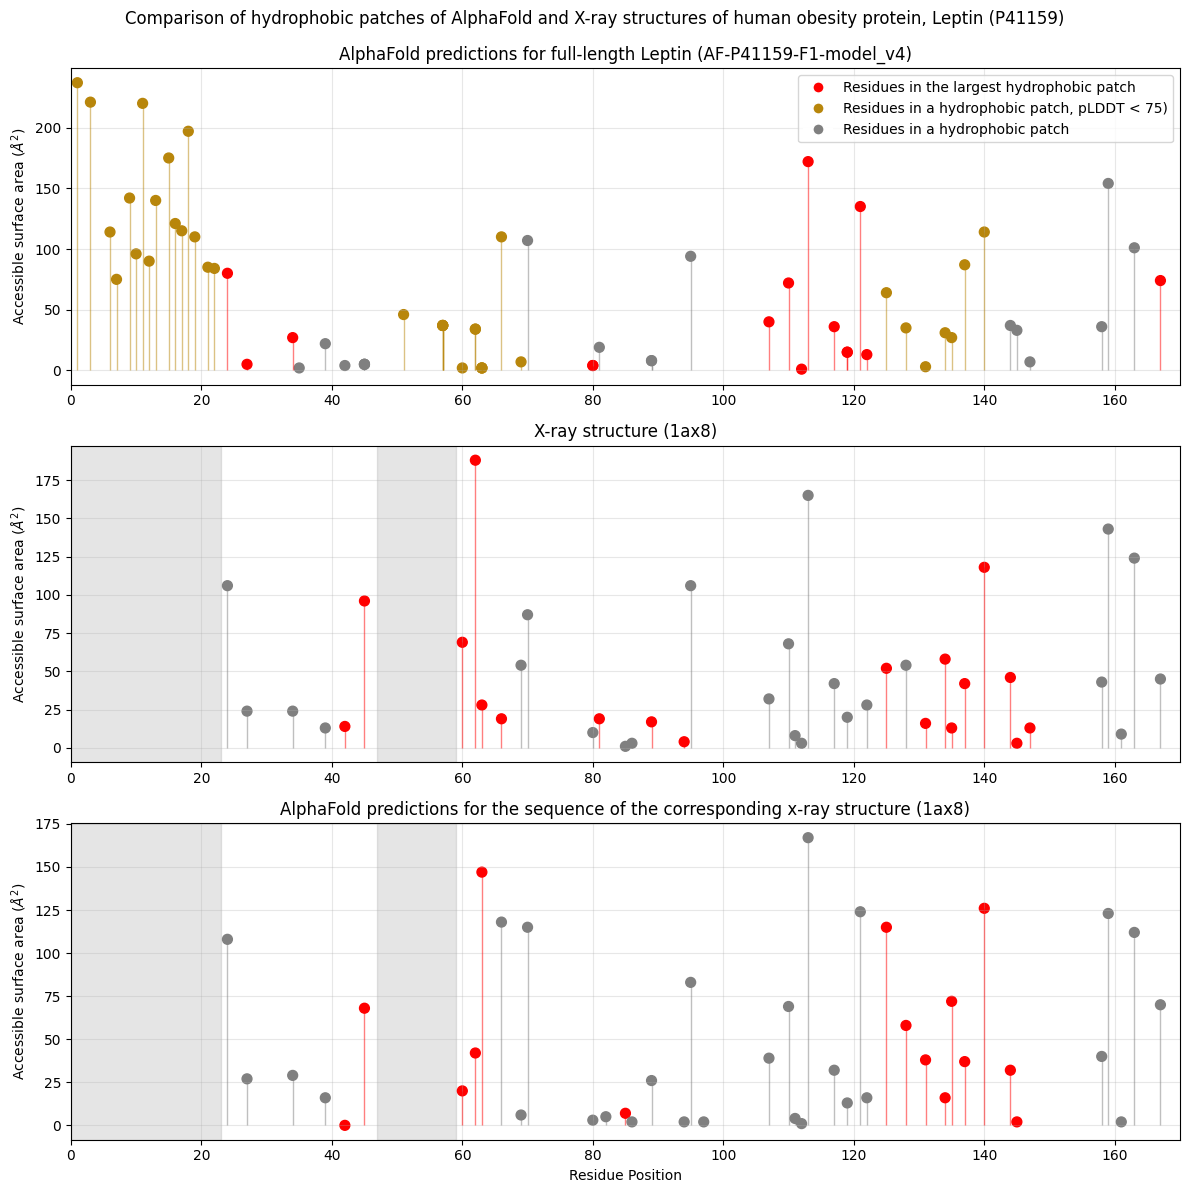

In [6]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 12), height_ratios=[1, 1, 1])
fig.subplots_adjust(hspace=0.3)

# Add grey shaded areas to the first plot
ax2.axvspan(0, 23, color='grey', alpha=0.2)
ax2.axvspan(47, 59, color='grey', alpha=0.2)

# Add grey shaded areas to the first plot
ax3.axvspan(0, 23, color='grey', alpha=0.2)
ax3.axvspan(47, 59, color='grey', alpha=0.2)

# Plot AlphaFold data (top)
colors_af = []  
for _, row in df_af.iterrows():
    # Default color based on pLDDT
    color = 'darkgoldenrod' if row['plddt'] < 75 else 'gray'
    
    # Override the color if the residue is present in the second dataset and patch_rank == 0
    if not df_af_corrected[df_af_corrected['residue_id'] == row['residue_id']].empty:
        if df_af_corrected[df_af_corrected['residue_id'] == row['residue_id']].iloc[0]['patch_rank'] == 0:
            color = 'red'
    
    colors_af.append(color)
    ax1.vlines(x=row['residue_id'], ymin=0, ymax=row['asa'], 
               colors=color, alpha=0.5, linewidth=1)

# Scatter plot with the updated colors
ax1.scatter(df_af['residue_id'], df_af['asa'], c=colors_af, s=50)

# Plot X-ray data (middle)
colors_xray = []
for _, row in df_xray.iterrows():
    color = 'red' if row['patch_rank'] == 0 else 'gray'
    colors_xray.append(color)
    ax2.vlines(x=row['residue_id'], ymin=0, ymax=row['asa'], 
               colors=color, alpha=0.5, linewidth=1)
ax2.scatter(df_xray['residue_id'], df_xray['asa'], c=colors_xray, s=50)

# Plot df_af_matched data (bottom)
colors_matched = []
for _, row in df_af_matched.iterrows():
    # Customize color logic for df_af_matched
    color = 'red' if row['patch_rank'] == 0 else 'gray'
    colors_matched.append(color)
    ax3.vlines(x=row['residue_id'], ymin=0, ymax=row['asa'], 
               colors=color, alpha=0.5, linewidth=1)
ax3.scatter(df_af_matched['residue_id'], df_af_matched['asa'], c=colors_matched, s=50)

# Customize each plot
ax1.set_title('AlphaFold predictions for full-length Leptin (AF-P41159-F1-model_v4)')
ax1.set_ylabel('Accessible surface area ($\AA^2$)')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 170)
ax1.set_xticks(np.arange(0, 171, 20))

ax2.set_title('X-ray structure (1ax8)')
ax2.set_ylabel('Accessible surface area ($\AA^2$)')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 170)
ax2.set_xticks(np.arange(0, 171, 20))

ax3.set_title('AlphaFold predictions for the sequence of the corresponding x-ray structure (1ax8)')
ax3.set_xlabel('Residue Position')
ax3.set_ylabel('Accessible surface area ($\AA^2$)')
ax3.grid(True, alpha=0.3)
ax3.set_xlim(0, 170)
ax3.set_xticks(np.arange(0, 171, 20))

# Add legend for AlphaFold plot
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', label='Residues in the largest hydrophobic patch', markersize=8),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='darkgoldenrod', label='Residues in a hydrophobic patch, pLDDT < 75)', markersize=8),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', label='Residues in a hydrophobic patch', markersize=8)
]
ax1.legend(handles=legend_elements, loc='upper right')

# Add common title
fig.suptitle('Comparison of hydrophobic patches of AlphaFold and X-ray structures of human obesity protein, Leptin (P41159)', y=0.99)

# Adjust layout & Save
plt.tight_layout()
plt.show()
fig.savefig('leptin_patches_comparison.png', dpi=300, bbox_inches='tight')
